# Image generation

This lab serves as the practical part for the image generation part. We will implement three different families of models: VAEs, GANs and Diffusion models. In this lab, we keep to the `basis` (to be taken with a grain of salt, because none of these models are actually basic or easy). Next lab will focus on diffusion models

In [2]:
import torch 
import torch.nn as nn 
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt 
import numpy as np

from collections import Counter
import os, random
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
import math
import re
import pandas as pd


os.makedirs("figures", exist_ok=True)
os.makedirs("samples", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)


In [3]:
def set_seed(seed):
    """Set seed"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f'Set seed {seed}')

set_seed(30)  # Use any number you like here
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Set seed 30
Device: cpu




We will start with using the MNIST dataset. This is an easy dataset containing handwritten numbers, and it lends itself very well for toy purposes. In the scope of training and comparing different models in this lab, it's a perfect model. You should be able to train different models and add/delete some layers and see what they do. But first, let's start with loading the data. 

The MNIST dataset is directly loadable from pytorch datasets.

In [4]:
batch_size = 128
ds_class = datasets.MNIST
DATASET_NAME = "MNIST"

# Data loader
transform = transforms.ToTensor()
                                
train_ds = datasets.MNIST(root='./data', train=True, transform=transform, download=True) # This is an already preloaded dataset from torch, making it very easy to load it. 
test_ds = datasets.MNIST(root='./data', train=False,transform=transform, download=True )


train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Next, let's visualize what this data looks like 



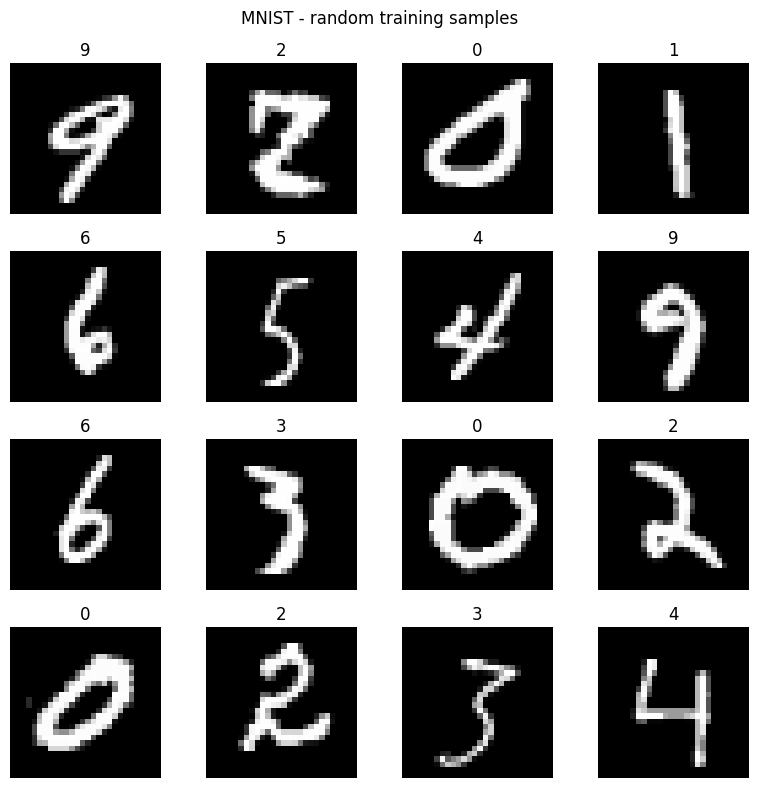

In [5]:
def show_grid(dataset, n=16, title="Samples"):
    idx = np.random.choice(len(dataset), n, replace=False)
    imgs = torch.stack([dataset[i][0] for i in idx])  # (n,1,28,28)
    labels = [dataset[i][1] for i in idx]

    cols = int(np.sqrt(n))
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*2, rows*2))
    for k in range(n):
        plt.subplot(rows, cols, k+1)
        plt.imshow(imgs[k].squeeze(0), cmap="gray")
        plt.title(str(labels[k]))
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_grid(train_ds, n=16, title=f"{DATASET_NAME} - random training samples")

In [6]:
num_samples = len(train_loader.dataset)
num_samples_test = len(test_loader.dataset)
print(f'There are {num_samples} samples in the train loader and {num_samples_test} in the test loader.')

There are 60000 samples in the train loader and 10000 in the test loader.


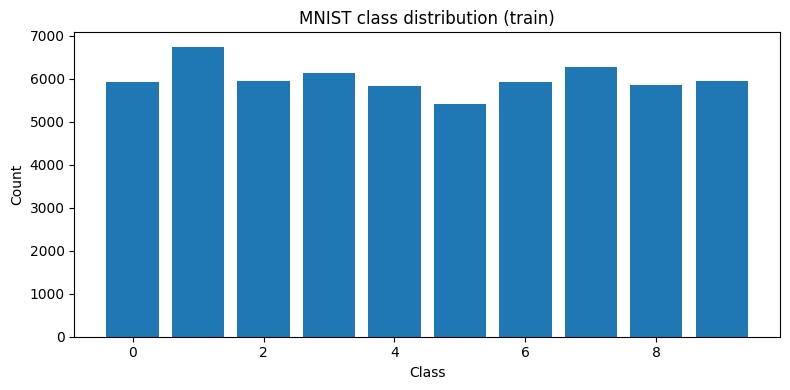

In [7]:
targets = [y for _, y in train_ds]
counts = Counter(targets)

plt.figure(figsize=(8,4))
plt.bar(list(counts.keys()), list(counts.values()))
plt.title(f"{DATASET_NAME} class distribution (train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Luckily, our dataset looks balanced enough, so we don't need to do anything in terms of data balancing. 



## Variational Autoencoders 
see also : [https://www.datacamp.com/tutorial/variational-autoencoders](https://www.datacamp.com/tutorial/variational-autoencoders)
Autoencoders are a type of neural network designed to learn efficient data representations, primarily for the purpose of dimensionality reduction or feature learning. 

Autoencoders consist of two main parts: 

- The encoder: Compresses the input data into a lower-dimensional latent space.
- The decoder: Reconstructs the original data from this compressed representation. 

The primary objective of autoencoders is to minimize the difference between the input and the reconstructed output, thus learning a compact representation of the data.

Enter Variational Autoencoders (VAEs), which extend the capabilities of the traditional autoencoder framework by incorporating probabilistic elements into the encoding process. 

While standard autoencoders map inputs to fixed latent representations, VAEs introduce a probabilistic approach where the encoder outputs a distribution over the latent space, typically modeled as a multivariate Gaussian. This allows VAEs to sample from this distribution during the decoding process, leading to the generation of new data instances.

The key innovation of VAEs lies in their ability to generate new, high-quality data by learning a structured, continuous latent space. This is particularly important for generative modeling, where the goal is not just to compress data but to create new data samples that resemble the original dataset. 

VAEs have demonstrated significant effectiveness in tasks such as image synthesis, data denoising, and anomaly detection, making them relevant tools for advancing the capabilities of machine learning models and applications.

We will start by importing the default libraries, as usual 

Now, specifically for VAEs we must define the Encoder, Decoder and then make the VAE. Below you can find some easy code for a very easy VAE. The encoder has just one layer, and so has the decoder. We call it FCVAE, short for Fully Connected VAE

In [8]:
latent_dim = 16

class FCVAE(nn.Module):
    def __init__(self, latent_dim=16, hidden=400):
        super().__init__()
        self.fc1 = nn.Linear(28*28, hidden)
        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)
        self.fc3 = nn.Linear(latent_dim, hidden)
        self.fc4 = nn.Linear(hidden, 28*28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z).view(-1, 1, 28, 28)
        return x_hat, mu, logvar

Next, we have to define the loss function. Remember that the loss function for a VAE consists of two parts: 
1) the reconstruction loss - to ensure that the output image looks like the original image
2) the KL divergence loss - to ensure that our latent space in between has a nice distribution - in this case a Gaussian normal distribution (because in practice, this is what we will use very often). To arive at the formula we used below, you need a whole page of mathematical derivations, so we will skip the theory and just use the formula 
    return BCE + KLD


In [9]:
def vae_loss(x, x_hat, mu, logvar, recon_loss="bce"):
    
    if recon_loss == "bce":
        recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
        
    elif recon_loss == "mse":
        recon = F.mse_loss(x_hat, x, reduction="sum")
        
    else:
        raise ValueError("recon_loss must be 'bce' or 'mse'")

    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon, kl, recon + kl

In [10]:

vae_fc = FCVAE(latent_dim=latent_dim).to(device)

We load one batch and check the output - sanity check that we are loading what we try to load - check the dimensions: do they make sense and are they what you expected them to be? 

In [11]:
x, _ = next(iter(train_loader))
x = x.to(device)
x_hat, mu, logvar = vae_fc(x)
print("x:", x.shape, "x_hat:", x_hat.shape, "mu:", mu.shape, "logvar:", logvar.shape)
print("x_hat range:", (x_hat.min().item(), x_hat.max().item()))

c:\Users\u0113512\Documents\advanced_ai\course-material-2526\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([128, 1, 28, 28]) x_hat: torch.Size([128, 1, 28, 28]) mu: torch.Size([128, 16]) logvar: torch.Size([128, 16])
x_hat range: (0.234632670879364, 0.7502659559249878)


### Helper functions

In [12]:

@torch.no_grad()
def evaluate_vae(model, loader, recon_loss="bce"):
    model.eval()
    total = 0.0
    total_recon = 0.0
    total_kl = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat, mu, logvar = model(x)
        recon, kl, loss = vae_loss(x, x_hat, mu, logvar, recon_loss=recon_loss)
        total += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        n += x.size(0)

    return {
        "loss": total / n,
        "recon": total_recon / n,
        "kl": total_kl / n
    }


@torch.no_grad()
def save_reconstructions(model, loader, path, n=16):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    x_hat, _, _ = model(x)
    # stack originals on top of reconstructions
    grid = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    save_image(make_grid(grid, nrow=n), path)


@torch.no_grad()
def save_random_samples(model, latent_dim, path, n=32):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    # both models expose decode()
    samples = model.decode(z).cpu()
    save_image(make_grid(samples, nrow=8), path)



### Finally, the function to train our model.
for now, we will run it with the baseline parameters. Later on, you can experiment with changing those and seeing if it makes any difference. 

In [13]:
def train_vae(model, name, train_loader, val_loader,
              epochs=15, lr=1e-3, recon_loss="bce", beta=1.0,
              sample_every=5):

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    best_val = float("inf")

    history = {"train_loss": [], "train_recon": [], "train_kl": [],
               "val_loss": [], "val_recon": [], "val_kl": []}

    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0
        n = 0

        for x, _ in train_loader:
            x = x.to(device)

            x_hat, mu, logvar = model(x)
            recon, kl, loss = vae_loss(x, x_hat, mu, logvar, recon_loss=recon_loss)
            loss = recon + beta * kl  # allow beta-VAE weighting

            optim.zero_grad()
            loss.backward()
            optim.step()

            running_loss += loss.item()
            running_recon += recon.item()
            running_kl += kl.item()
            n += x.size(0)

        train_metrics = {
            "loss": running_loss / n,
            "recon": running_recon / n,
            "kl": running_kl / n
        }
        val_metrics = evaluate_vae(model, val_loader, recon_loss=recon_loss)

        history["train_loss"].append(train_metrics["loss"])
        history["train_recon"].append(train_metrics["recon"])
        history["train_kl"].append(train_metrics["kl"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_recon"].append(val_metrics["recon"])
        history["val_kl"].append(val_metrics["kl"])

        print(f"[{name}] Epoch {ep:02d} | "
              f"train: loss={train_metrics['loss']:.4f} recon={train_metrics['recon']:.4f} kl={train_metrics['kl']:.4f} | "
              f"val: loss={val_metrics['loss']:.4f} recon={val_metrics['recon']:.4f} kl={val_metrics['kl']:.4f}")

        # Save best
        if val_metrics["loss"] < best_val:
            best_val = val_metrics["loss"]
            torch.save(model.state_dict(), f"checkpoints/{name}_best.pt")
            print(f"  -> saved BEST: checkpoints/{name}_best.pt")

        # Periodic samples
        if (ep % sample_every) == 0 or ep == 1:
            save_reconstructions(model, val_loader, f"samples/{name}_recon_ep{ep:02d}.png", n=16)
            save_random_samples(model, latent_dim, f"samples/{name}_rand_ep{ep:02d}.png", n=32)

    # Final save
    torch.save(model.state_dict(), f"checkpoints/{name}_last.pt")
    print(f"[{name}] saved LAST: checkpoints/{name}_last.pt")

    return history

In [14]:
epochs = 100
lr = 1e-3

hist_fc = train_vae(vae_fc, "vae_fc", train_loader, test_loader,
                    epochs=epochs, lr=lr, recon_loss="bce", beta=1.0, sample_every=5)

[vae_fc] Epoch 01 | train: loss=163.5441 recon=148.3971 kl=15.1471 | val: loss=125.8492 recon=105.1694 kl=20.6798
  -> saved BEST: checkpoints/vae_fc_best.pt
[vae_fc] saved LAST: checkpoints/vae_fc_last.pt


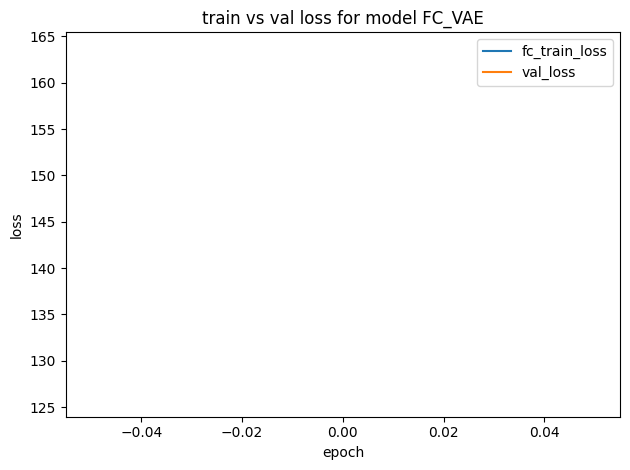

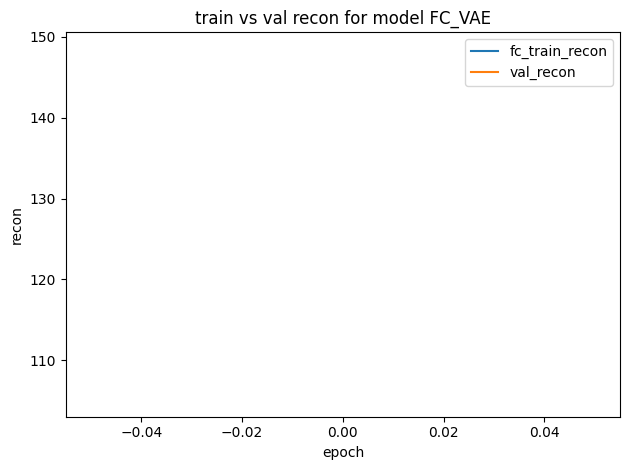

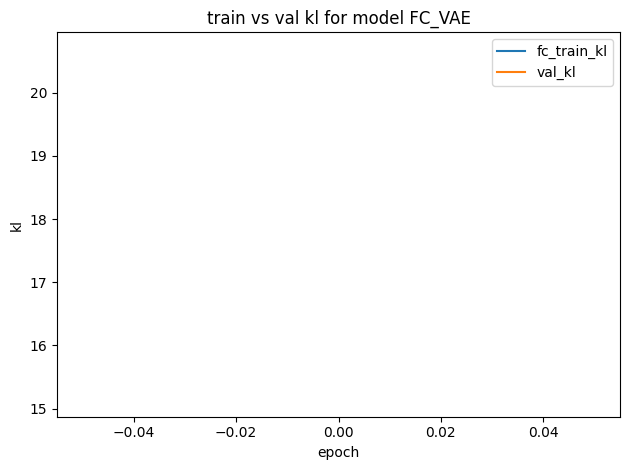

In [15]:
# history = {"train_loss": [], "train_recon": [], "train_kl": [],
            #    "val_loss": [], "val_recon": [], "val_kl": []}

metrics = ['loss', 'recon', 'kl']
for metric in metrics: 
    plt.figure()
    plt.plot(hist_fc[f'train_{metric}'], label=f"fc_train_{metric}")
    plt.plot(hist_fc[f'val_{metric}'], label=f"val_{metric}")
    plt.title(f'train vs val {metric} for model FC_VAE')
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [16]:
fc_train  = evaluate_vae(vae_fc,  train_loader, recon_loss="bce")
fc_val    = evaluate_vae(vae_fc,  test_loader,  recon_loss="bce")


print("FC  gap (val-train):",  fc_val["loss"] -  fc_train["loss"])

FC  gap (val-train): -1.0759702392578134


Once we have trained the model, as you should know very well by now, we of course want to evaluate it. 
Let's visualize the reconstructed output and the generated samples. Our code automatically stored the weights of the best model in the 'checkpoints' folder, so let's load this one.  

In [18]:
vae_fc.load_state_dict(torch.load("checkpoints/vae_fc_best.pt", map_location=device))
vae_fc.eval()

FCVAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

In [19]:
@torch.no_grad()
def show_grid(imgs, nrow=8, title=""):
    grid = make_grid(imgs.cpu(), nrow=nrow, padding=2)
    plt.figure(figsize=(12, 4))
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

@torch.no_grad()
def recon_grid(model, loader, n=16, title="Reconstructions"):
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    x_hat, _, _ = model(x)
    # top row originals, bottom row recon
    both = torch.cat([x, x_hat], dim=0)
    show_grid(both, nrow=n, title=title)
    return x, x_hat

@torch.no_grad()
def random_samples(model, latent_dim, n=32, title="Random samples"):
    z = torch.randn(n, latent_dim, device=device)
    samples = model.decode(z)
    print(samples.shape)
    if samples.dim() == 2:            
        samples = samples.view(-1, 1, 28, 28)
    show_grid(samples, nrow=8, title=title)
    return samples

@torch.no_grad()
def latent_interpolation(model, loader, steps=11, use_mean=True, title="Latent interpolation"):
    x, _ = next(iter(loader))
    x0 = x[0:1].to(device)
    x1 = x[1:2].to(device)

    is_fc = hasattr(model, "fc1")  

    x0_in = x0.view(x0.size(0), -1) if is_fc else x0
    x1_in = x1.view(x1.size(0), -1) if is_fc else x1

    mu0, logvar0 = model.encode(x0_in)
    mu1, logvar1 = model.encode(x1_in)

    if use_mean:
        z0, z1 = mu0, mu1
    else:
        z0 = model.reparameterize(mu0, logvar0)
        z1 = model.reparameterize(mu1, logvar1)

    alphas = torch.linspace(0, 1, steps, device=device).unsqueeze(1)
    z = (1 - alphas) * z0 + alphas * z1

    out = model.decode(z)

    if out.dim() == 2:            
        out = out.view(-1, 1, 28, 28)

    imgs = torch.cat([x0, out, x1], dim=0)  
    show_grid(imgs, nrow=steps + 2, title=title)
    return imgs

@torch.no_grad()
def traversal_1d(model, latent_dim, dim=0, steps=11, scale=3.0, title="Latent traversal"):
    z = torch.randn(1, latent_dim, device=device)
    vals = torch.linspace(-scale, scale, steps, device=device)

    zs = z.repeat(steps, 1)
    zs[:, dim] = vals
    out = model.decode(zs)

    if out.dim() == 2:  # (steps, 784)
        out = out.view(-1, 1, 28, 28)

    show_grid(out, nrow=steps, title=title)
    return out

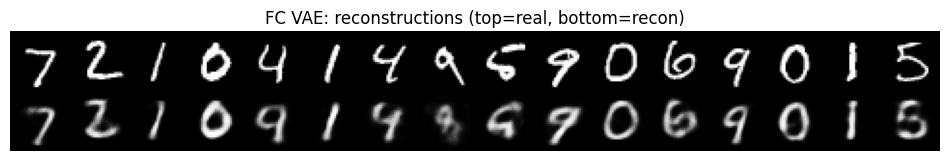

torch.Size([32, 784])


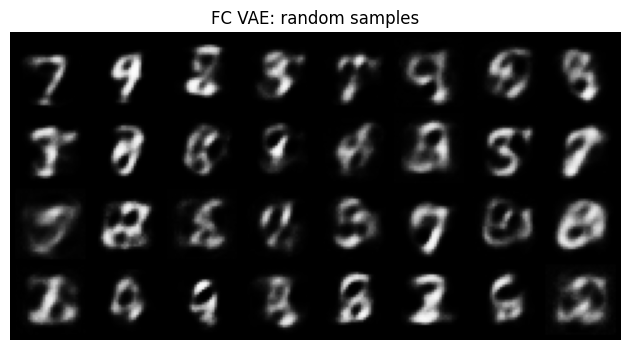

tensor([[[[5.6039e-04, 8.2138e-04, 8.0627e-04,  ..., 5.8177e-04,
           3.9251e-04, 6.7177e-04],
          [6.3091e-04, 5.8679e-04, 1.0483e-03,  ..., 9.1727e-04,
           8.2402e-04, 5.6335e-04],
          [5.9758e-04, 5.0878e-04, 7.7033e-04,  ..., 5.5793e-04,
           8.5765e-04, 8.2199e-04],
          ...,
          [6.5193e-04, 8.0568e-04, 6.9800e-04,  ..., 7.1000e-04,
           5.3502e-04, 1.0490e-03],
          [8.8271e-04, 7.9461e-04, 4.5199e-04,  ..., 8.6121e-04,
           8.6610e-04, 6.2789e-04],
          [7.4143e-04, 5.4436e-04, 4.1991e-04,  ..., 6.2303e-04,
           9.3986e-04, 9.2309e-04]]],


        [[[2.9024e-05, 5.1857e-05, 3.7273e-05,  ..., 2.3268e-05,
           1.9392e-05, 1.5443e-05],
          [2.9766e-05, 3.0614e-05, 2.6852e-05,  ..., 2.0710e-05,
           4.2161e-05, 1.7913e-05],
          [5.2893e-05, 5.3380e-06, 1.2154e-05,  ..., 2.1209e-05,
           1.7885e-05, 2.6241e-05],
          ...,
          [3.4968e-05, 2.3361e-05, 1.6292e-05,  ..., 1.75

In [20]:
recon_grid(vae_fc,  test_loader, n=16, title="FC VAE: reconstructions (top=real, bottom=recon)")

random_samples(vae_fc,  latent_dim, n=32, title="FC VAE: random samples")



This output is quite typically what happens with VAEs:
- the reconstructed images are a lot more blurry than the original ones 
- the reconstructed images are in this case not very good. Of course, our model was not very big and also not training for a long time 

### Latent interpolation 

One of the key features of VAEs are that we modeled this latent space which has a meaningful distribution. This means that we can **traverse** the latent space: we start with a sampled point and then move a bit further in this space, to generate a new z. You can see what this gives with this particular model below. Try to interpret the resuls below: go back to the code where they were generated and see what actually happens 

c:\Users\u0113512\Documents\advanced_ai\course-material-2526\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


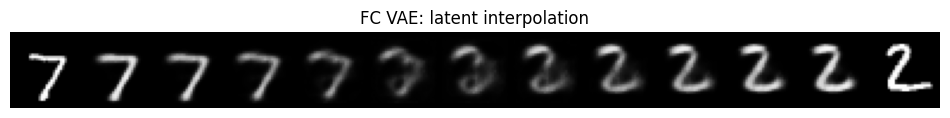

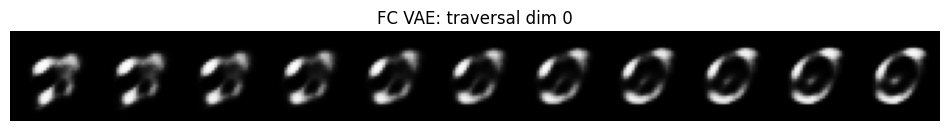

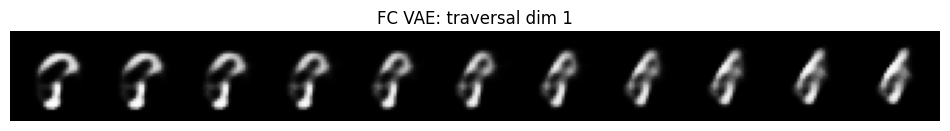

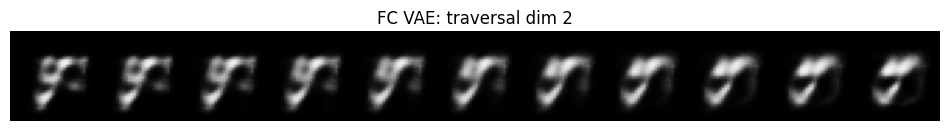

In [102]:
latent_interpolation(vae_fc,  test_loader, steps=11, use_mean=True, title="FC VAE: latent interpolation")
for d in [0, 1, 2]:
    traversal_1d(vae_fc,  latent_dim, dim=d, steps=11, scale=3.0, title=f"FC VAE: traversal dim {d}")

### Now: let's play around with models and see if we can improve this

Now, since we work with images, fully connected layers in which we flatten all of our data, will probably not yield the best result. Below, we will also implement a Convolutional VAE. This one uses Convolutional layers instead of Fully connected ones. 

### Tasks to implement: 
- complete the convolutional layers of the ConvVAE below. Both the Encoder and the decoder miss one convolutional layer in the middle, which you will have to implement. Basically, you have to find the correct dimensions: go and look up what these numbers mean and try to make it fit `### ADD ONE LAYER HERE!!!`
- once this model runs, you can train and evaluate it in the same way as we did for the simple FC model above. 
- Train the model and compare its performance to that of the basic model. Which one do you prefer? 
- Once we have chosen our favorite model, there are more things we can optimize. In the function `train_vae`, there is an optional paramter beta = 1.0. This actually lets up implement one of the optimalisations of VAE, called β-VAE. 


#### What is a β-VAE?

The β-VAE (beta Variational Autoencoder) is a modification of the traditional VAE that introduces a hyperparameter, β (beta), to balance the trade-off between the reconstruction loss and the KL divergence loss:

In β-VAE, the KL divergence term is weighted by β, which controls how much importance is given to this term.

By increasing β (typically β > 1), the model is encouraged to learn more disentangled representations in the latent space, which can be useful for interpretability and for generating factors of variation in the generated images. When β = 1, it reduces to the standard VAE.

So we simply put this parameter in our loss ( go and check this out)



In [ ]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: (B,1,28,28) -> (B,128,7,7)
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 28 -> 14
            nn.ReLU(inplace=True),
            ### ADD ONE LAYER HERE!!!
            nn.Conv2d(64, 128, 3, 1, 1), # 7 -> 7
            nn.ReLU(inplace=True),
        )
        self.enc_flat_dim = 128 * 7 * 7
        self.fc_mu = nn.Linear(self.enc_flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_flat_dim, latent_dim)

        # Decoder: latent -> (B,128,7,7) -> (B,1,28,28)
        self.fc_dec = nn.Linear(latent_dim, self.enc_flat_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 7 -> 14
            nn.ReLU(inplace=True),
            ### ADD ONE LAYER HERE!!!
            nn.Conv2d(32, 1, 3, 1, 1),             # keep 28
            nn.Sigmoid(),                          # for BCE w/ inputs in [0,1]
        )

    def encode(self, x):
        h = self.enc(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # z = mu + std * eps
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z).view(z.size(0), 128, 7, 7)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

## Generative Adversarial Networks 

Next up in the image generation family: GANs! 

We will train a GAN and then do the same task, to see how well it compares against the VAE. 
GANs consist of a generator and a discriminator. The generator generates new images from random noise, and the discriminator tries to distinguish between real and generated images. 
The models are trained in an adversarial manner (hence the name GAN), with the generator trying to fool the discriminator, and the discriminator trying to classify real vs generated image. 



In [ ]:
z_dim = 100 # latent noise dimension --> Where we sample from at the start 


We need some helper functions 

In [10]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def weights_init(m):

    classname = m.__class__.__name__
    if classname.find("Conv") != -1 or classname.find("Linear") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

Now, let us define the Generator and the Discriminator blocks. The generator takes in a noise vector and outputs an image, while the discriminator will take in an image and output a probability, indicating whether the image is fake or real 

In [ ]:
def maybe_spectral_norm(layer, use_sn: bool):
    return nn.utils.spectral_norm(layer) if use_sn else layer


class G_MNIST(nn.Module):
    """
    z -> 28x28
    out_act:
      - "sigmoid" for baseline on [0,1]
      - "tanh"    for improved on [-1,1]
    """
   
    def __init__(self, z_dim=64, base_ch=64, out_act="tanh"):
        super().__init__()
        self.z_dim = z_dim
        self.fc = nn.Linear(z_dim, base_ch*4*7*7)

        self.net = nn.Sequential(
            nn.BatchNorm2d(base_ch*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, 2, 1),  # 7->14
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_ch*2, base_ch, 4, 2, 1),    # 14->28
            nn.BatchNorm2d(base_ch),
            nn.ReLU(True),

            nn.Conv2d(base_ch, 1, 3, 1, 1),                     # keep 28x28
        )

        if out_act == "sigmoid":
            self.out = nn.Sigmoid()
        elif out_act == "tanh":
            self.out = nn.Tanh()
        else:
            raise ValueError("out_act must be 'sigmoid' or 'tanh'")

    def forward(self, z):
        x = self.fc(z).view(z.size(0), -1, 7, 7)
        x = self.net(x)
        return self.out(x)
    

class D_MNIST(nn.Module):
    """
    in: (B,1,28,28)
    out:
      - prob (sigmoid)  for baseline + BCELoss
      - logits (no sigmoid) for improved + BCEWithLogitsLoss
    """
    def __init__(self, base_ch=64, out_mode="logits", use_spectral_norm=False):
        super().__init__()
        self.out_mode = out_mode

        self.conv = nn.Sequential(
            maybe_spectral_norm(nn.Conv2d(1, base_ch, 4, 2, 1), use_spectral_norm),  # 28->14
            nn.LeakyReLU(0.2, inplace=True),

            maybe_spectral_norm(nn.Conv2d(base_ch, base_ch*2, 4, 2, 1), use_spectral_norm),  # 14->7
            nn.LeakyReLU(0.2, inplace=True),

            maybe_spectral_norm(nn.Conv2d(base_ch*2, base_ch*4, 3, 1, 1), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            maybe_spectral_norm(nn.Linear(base_ch*4*7*7, 1), use_spectral_norm)
        )

        if out_mode == "prob":
            self.out = nn.Sigmoid()
        elif out_mode == "logits":
            self.out = nn.Identity()
        else:
            raise ValueError("out_mode must be 'prob' or 'logits'")

    def forward(self, x):
        h = self.conv(x)
        y = self.fc(h)
        return self.out(y)

In [25]:

# Initialize the generator and the discriminator
G = G_MNIST(z_dim=z_dim).to(device)
D = D_MNIST().to(device)

#initialize the weights according to what layer they are - different layers will use a different weight init (these are the common values that tend to work well )
G.apply(weights_init)
D.apply(weights_init)


print("G params:", count_params(G))
print("D params:", count_params(D))


G params: 1923969
D params: 440001


We see that this is not a small model anymore - the Generator has ~1.9M parameters and the Discriminator has ~440k.

Below, we again do some sanity checks to see if we get the expected outputs. Take a look at what we are printing and what the output is. Is this according to what you would expect? 

In [26]:
x_real, _ = next(iter(train_loader))
x_real = x_real[:8].to(device)

z = torch.randn(8, z_dim, device=device)
x_fake = G(z)
d_real = D(x_real)
d_fake = D(x_fake)

print("x_real:", x_real.shape, "range:", (float(x_real.min()), float(x_real.max())))
print("x_fake:", x_fake.shape, "range:", (float(x_fake.min()), float(x_fake.max())))
print("D(x_real):", d_real.shape, "range:", (float(d_real.min()), float(d_real.max())))
print("D(x_fake):", d_fake.shape, "range:", (float(d_fake.min()), float(d_fake.max())))

c:\Users\u0113512\Documents\advanced_ai\course-material-2526\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x_real: torch.Size([8, 1, 28, 28]) range: (0.0, 1.0)
x_fake: torch.Size([8, 1, 28, 28]) range: (-0.6764793395996094, 0.8699585199356079)
D(x_real): torch.Size([8, 1]) range: (-0.014237718656659126, 0.004973666742444038)
D(x_fake): torch.Size([8, 1]) range: (-0.0023251608945429325, 0.008272543549537659)


Below we can see the loss as we saw it for the standard GAN. There are two other loss functions below, which are more commonly used because they have better training properties, but we will start by implementing just the first loss

| Formulation                                                                       | Discriminator Loss ($L_D$)                                                                                                                                                        | Generator Loss ($L_G$)                   |
|--------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------|
| MinMax (standard)      | $-\mathbb{E}_{x\sim p_d} [\log(D(x))]- \mathbb{E}_{\hat{x}\sim p_g} [\log (1-D(\hat{x}))]$ | $\mathbb{E}_{\hat{x}\sim p_g} [\log (1-D(\hat{x}))]$                                                                                                                                       |
| Non-Saturating                                                                             | $ -\mathbb{E}_{x\sim p_d} [\log(D(x))]+\mathbb{E}_{\hat{x}\sim p_g} [\log (D(\hat{x}))]$                                                                                                   | $-\mathbb{E}_{\hat{x}\sim p_g} [\log (D(\hat{x}))]$ |
| WGAN-GP                                                                                    | $-\mathbb{E}_{x\sim p_d} [D(x)] + \mathbb{E}_{\hat{x}\sim p_g} [D(\hat{x})] + \lambda \mathbb{E}_{\hat{x} \sim p_{g}} \left[(\|\nabla D(\alpha x + (1-\alpha \hat{x})) \|_2 -1)^2 \right]$ | $-\mathbb{E}_{\hat{x}\sim p_g} [D(\hat{x})]$        |


In [15]:
@torch.no_grad()
def show_grid_imgs(imgs, nrow=8, title=""):
    grid = make_grid(imgs.cpu(), nrow=nrow, padding=2)
    plt.figure(figsize=(10, 4))
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

@torch.no_grad()
def save_samples(G, z_fixed, path=None, title=""):
    G.eval()
    x = G(z_fixed).clamp(0, 1)
    if path is not None:
        save_image(make_grid(x.cpu(), nrow=8), path)
    show_grid_imgs(x, nrow=8, title=title)
    return x

# Binary crossentropy 
def bce(prob, target):
    return F.binary_cross_entropy(prob, target)

### Now, we have defined the Generator and the discriminator. Let's define the training loop!

In [27]:
def train_gan(
    name,
    G,
    D,
    train_loader,
    epochs=50,
    z_dim=64,
    lr=2e-4,
    betas=(0.5, 0.999),
    # labels must be [1,0] as requested:
    real_label=1.0,
    fake_label=0.0,
    use_logits_loss=True,            
    instance_noise=True,             # add Gaussian noise to D inputs, anneal to 0
    noise_sigma_start=0.15,
    noise_sigma_end=0.0,
    grad_clip=None,                  
    sample_every=20,
    data_range="m11"                 
):
    G.to(device); D.to(device)

    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=betas)
    optD = torch.optim.Adam(D.parameters(), lr=lr, betas=betas)

    crit = nn.BCEWithLogitsLoss() if use_logits_loss else nn.BCELoss()

    z_fixed = torch.randn(64, z_dim, device=device)

    hist = {"D_loss": [], "G_loss": []}
    best_g = float("inf")

    for ep in range(1, epochs+1):
        G.train(); D.train()

        # instance-noise schedule
        if instance_noise:
            t = (ep - 1) / max(1, (epochs - 1))
            sigma = noise_sigma_start * (1 - t) + noise_sigma_end * t
        else:
            sigma = 0.0

        d_running, g_running, nb = 0.0, 0.0, 0

        for x_real, _ in train_loader:
            x_real = x_real.to(device)
            bs = x_real.size(0)

            y_real = torch.full((bs, 1), real_label, device=device)
            y_fake = torch.full((bs, 1), fake_label, device=device)

            # Train D
            z = torch.randn(bs, z_dim, device=device)
            x_fake = G(z).detach()

            xr = x_real
            xf = x_fake
            if sigma > 0:
                xr = (xr + sigma * torch.randn_like(xr)).clamp(-1, 1) if data_range == "m11" else (xr + sigma * torch.randn_like(xr)).clamp(0, 1)
                xf = (xf + sigma * torch.randn_like(xf)).clamp(-1, 1) if data_range == "m11" else (xf + sigma * torch.randn_like(xf)).clamp(0, 1)

            out_real = D(xr)
            out_fake = D(xf)

            d_loss = crit(out_real, y_real) + crit(out_fake, y_fake)

            optD.zero_grad(set_to_none=True)
            d_loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(D.parameters(), grad_clip)
            optD.step()

            # Train G
            z = torch.randn(bs, z_dim, device=device)
            x_fake = G(z)

            xf = x_fake
            if sigma > 0:
                xf = (xf + sigma * torch.randn_like(xf)).clamp(-1, 1) if data_range == "m11" else (xf + sigma * torch.randn_like(xf)).clamp(0, 1)

            out_fake = D(xf)
            g_loss = crit(out_fake, y_real)  

            optG.zero_grad(set_to_none=True)
            g_loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(G.parameters(), grad_clip)
            optG.step()

            d_running += d_loss.item()
            g_running += g_loss.item()
            nb += 1

        d_ep = d_running / nb
        g_ep = g_running / nb
        hist["D_loss"].append(d_ep)
        hist["G_loss"].append(g_ep)

        print(f"[{name}] Ep {ep:03d} | D_loss={d_ep:.4f} | G_loss={g_ep:.4f} | sigma={sigma:.4f}")

        # save best by G_loss (simple)
        if g_ep < best_g:
            best_g = g_ep
            torch.save(G.state_dict(), f"checkpoints/{name}_G_best.pt")
            torch.save(D.state_dict(), f"checkpoints/{name}_D_best.pt")

        # periodic snapshots
        if ep == 1 or ep % sample_every == 0 or ep == epochs:
            save_samples(G, z_fixed, f"samples/{name}_ep{ep:03d}.png",
                         title=f"{name}: samples (ep {ep})", data_range=data_range)

    torch.save(G.state_dict(), f"checkpoints/{name}_G_last.pt")
    torch.save(D.state_dict(), f"checkpoints/{name}_D_last.pt")
    print(f"[{name}] saved LAST: checkpoints/{name}_G_last.pt, checkpoints/{name}_D_last.pt")

    # plot losses for this run
    plt.figure()
    plt.plot(hist["D_loss"], label="D_loss")
    plt.plot(hist["G_loss"], label="G_loss")
    plt.title(f"{name} training losses")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"figures/{name}_losses.png", dpi=150)
    plt.show()

    return hist, z_fixed

In [ ]:
z_dim = 64
epochs = 100

G_base = G_MNIST(z_dim=z_dim, out_act="sigmoid").to(device)     # output [0,1]
D_base = D_MNIST(out_mode="prob", use_spectral_norm=False).to(device)  # outputs prob (sigmoid)


batch_size = 128

tf_01 = transforms.ToTensor()
train_ds_base = datasets.MNIST("./data", train=True, download=True, transform=tf_01)
test_ds_base  = datasets.MNIST("./data", train=False, download=True, transform=tf_01)

train_loader_base = DataLoader(train_ds_base, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader_base  = DataLoader(test_ds_base,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

hist_base, z_fixed = train_gan(
    name="task5_gan_baseline_sigmoid",
    G=G_base, D=D_base,
    train_loader=train_loader_base,
    epochs=epochs,
    z_dim=z_dim,
    lr=2e-4, betas=(0.5, 0.999),
    real_label=1.0, fake_label=0.0,           
    use_logits_loss=False,                    
    instance_noise=False,                     
    grad_clip=None,
    sample_every=20,
    data_range="01"
)

[task5_gan_baseline_sigmoid] Ep 001 | D_loss=1.0475 | G_loss=1.2948 | sigma=0.0000


TypeError: save_samples() got an unexpected keyword argument 'data_range'

Now, we can look at the loss plots of the Generator versus the Discriminator. Note how they balance each other out and they are competing with one another, before they finally converge to the final value 

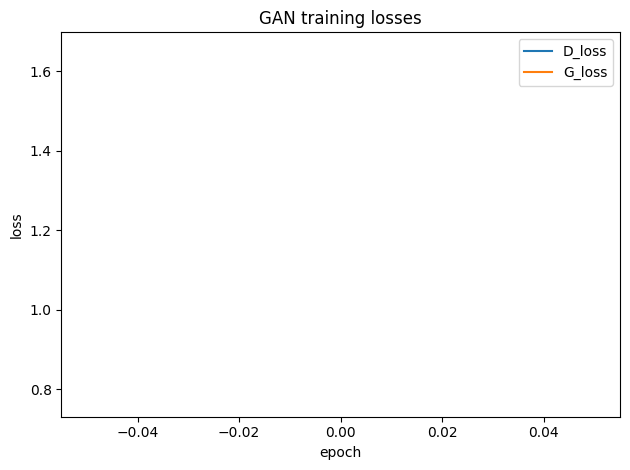

In [ ]:
plt.figure()
plt.plot(hist_base["D_loss"], label="D_loss")
plt.plot(hist_base["G_loss"], label="G_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("GAN training losses")
plt.legend()
plt.tight_layout()
plt.show()

## GAN stability

In reality, GANs are often hard to train and tend to collapse easily. Let's implement some tricks such that they train more stable. 


#### On the data front: 

First of all, we can normalize our input data, as is done below using the data loader 


In [ ]:
# This is what we did before
tf_01 = transforms.ToTensor()

#Now, we add normalization to the data
tf_m11 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [0,1] -> [-1,1]
])

In [ ]:
batch_size = 128
train_ds_base = datasets.MNIST("./data", train=True, download=True, transform=tf_01)
test_ds_base  = datasets.MNIST("./data", train=False, download=True, transform=tf_01)

train_loader_base = DataLoader(train_ds_base, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader_base  = DataLoader(test_ds_base,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

train_ds_imp  = datasets.MNIST("./data", train=True, download=True, transform=tf_m11)
test_ds_imp   = datasets.MNIST("./data", train=False, download=True, transform=tf_m11)



train_loader_imp  = DataLoader(train_ds_imp,  batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader_imp   = DataLoader(test_ds_imp,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

#### On the model front: 
Quite a lot of people at one point put in a lot of research and came up with the following optimizations. Since they researched it so hard, we will implement them and verify if they were actually correct


we changed some things in our model: 
- the output function of the Generator changed from `sigmoids` to the  `tanh` activation function 
    out_act:
      - "sigmoid" for baseline with values in between [0,1]
      - "tanh"    for improved with values in between [-1,1]
- we output the values of the discriminator as logits (just the values they are), instead of using a sigmoid activation function. In practice this works better
- we use the `spectral norm` for the Discriminator layers. This is some sort of special normalization which has been proposed for GANs and improves their stability. 



In [ ]:

G_imp = G_MNIST(z_dim=z_dim, out_act="tanh").to(device)         
D_imp = D_MNIST(out_mode="logits", use_spectral_norm=True).to(device)  

hist_imp, _ = train_gan(
    name="task5_gan_improved_logits_SN",
    G=G_imp, D=D_imp,
    train_loader=train_loader_imp,
    epochs=epochs,
    z_dim=z_dim,
    lr=2e-4, betas=(0.5, 0.999),
    real_label=1.0, fake_label=0.0,           
    use_logits_loss=True,                     
    instance_noise=True,                      
    noise_sigma_start=0.15, noise_sigma_end=0.0,
    grad_clip=1.0,                            
    sample_every=20,
    data_range="m11"
)

### Task: run the two models and compare their output 
- both quantitatively by looking at the images 
- and qualitatively by looking at the loss curves (try to plot them on the same plot to be able to compare)


You can run the code below to load your model checkpoints, if you already trained them in a previous session. Skip the block below, the one below that will actually load the functions. 

### Task: compare VAE and GANs
now that you have trained a model on the same dataset, compare your findings. 
- which model do you look more?
- which one gives better results?
- which one is the fastest to train? 
- If you had to further experiment, which one would you choose?
- Do you have a bit more of an idea of when to use each of these models?

In [29]:
def safe_torch_load(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

def normalize_state_dict(raw):
    if isinstance(raw, dict) and "state_dict" in raw and isinstance(raw["state_dict"], dict):
        raw = raw["state_dict"]
    if isinstance(raw, dict) and "model_state_dict" in raw and isinstance(raw["model_state_dict"], dict):
        raw = raw["model_state_dict"]
    sd = {}
    for k, v in raw.items():
        sd[k.replace("module.", "")] = v
    return sd

def max_index(sd, prefix):
    pat = re.compile(rf"^{re.escape(prefix)}(\d+)\.")
    mx = -1
    for k in sd.keys():
        m = pat.match(k)
        if m:
            mx = max(mx, int(m.group(1)))
    return mx

def has_any_prefix(sd, prefix):
    return any(k.startswith(prefix) for k in sd.keys())

def _get_weight_key(sd, base):
    if f"{base}.weight_orig" in sd:
        return "weight_orig", True
    if f"{base}.weight" in sd:
        return "weight", False
    return None, False

def _is_bn(sd, base):
    wkey, _ = _get_weight_key(sd, base)
    if wkey is None:
        return False
    return (sd[f"{base}.{wkey}"].ndim == 1) and (f"{base}.running_mean" in sd) and (f"{base}.running_var" in sd)

def _is_linear(sd, base):
    wkey, _ = _get_weight_key(sd, base)
    return (wkey is not None) and (sd[f"{base}.{wkey}"].ndim == 2)

def _is_conv(sd, base):
    wkey, _ = _get_weight_key(sd, base)
    return (wkey is not None) and (sd[f"{base}.{wkey}"].ndim == 4)

def make_layer_from_ckpt(sd, base):
    wkey, spectral = _get_weight_key(sd, base)
    if wkey is None:
        return None

    w = sd[f"{base}.{wkey}"]

    if _is_bn(sd, base):
        c = int(w.shape[0])
        return nn.BatchNorm2d(c)

    if w.ndim == 2:
        out_f, in_f = int(w.shape[0]), int(w.shape[1])
        layer = nn.Linear(in_f, out_f, bias=(f"{base}.bias" in sd))
        if spectral:
            layer = spectral_norm(layer)
        return layer

    if w.ndim == 4:
        k = int(w.shape[2])
        if k == 4:
            stride, pad = 2, 1
        elif k == 3:
            stride, pad = 1, 1
        else:
            stride, pad = 1, 0

        bias_len = int(sd[f"{base}.bias"].shape[0]) if f"{base}.bias" in sd else None

        out_ch_conv, in_ch_conv = int(w.shape[0]), int(w.shape[1])  # Conv2d
        in_ch_t, out_ch_t       = int(w.shape[0]), int(w.shape[1])  # ConvT

        use_transpose = False
        if bias_len is not None:

            if bias_len == out_ch_t and bias_len != out_ch_conv:
                use_transpose = True

        if use_transpose:
            layer = nn.ConvTranspose2d(in_ch_t, out_ch_t, kernel_size=k, stride=stride, padding=pad,
                                       bias=(bias_len is not None))
        else:
            layer = nn.Conv2d(in_ch_conv, out_ch_conv, kernel_size=k, stride=stride, padding=pad,
                              bias=(bias_len is not None))

        if spectral:
            layer = spectral_norm(layer)
        return layer

    return None

def build_indexed_sequential(sd, prefix, role):
    """
    Builds Sequential aligned to checkpoint indices.
    If an index has no params -> insert plausible activation.
    """
    mx = max_index(sd, prefix)
    if mx < 0:
        return nn.Sequential()

    layers = []
    for i in range(mx + 1):
        base = f"{prefix}{i}"
        layer = make_layer_from_ckpt(sd, base)
        if layer is None:
            layers.append(nn.ReLU(inplace=True) if role == "gen" else nn.LeakyReLU(0.2, inplace=True))
        else:
            layers.append(layer)
    return nn.Sequential(*layers)

def safe_torch_load(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

def normalize_state_dict(raw):
    if isinstance(raw, dict) and "state_dict" in raw and isinstance(raw["state_dict"], dict):
        raw = raw["state_dict"]
    if isinstance(raw, dict) and "model_state_dict" in raw and isinstance(raw["model_state_dict"], dict):
        raw = raw["model_state_dict"]
    sd = {}
    for k, v in raw.items():
        sd[k.replace("module.", "")] = v
    return sd

class GeneratorAuto(nn.Module):
    """
    Supports checkpoints with:
      - fc.* and net.i.*
      - or net.i.* only
    Key fix: before BatchNorm2d, if input is flat (B, C*H*W), reshape to (B,C,H,W).
    """
    def __init__(self, sd, force_output=None):
        super().__init__()
        self.force_output = force_output

        self.fc = None
        if ("fc.weight" in sd) or ("fc.weight_orig" in sd):
            wkey, spectral = _get_weight_key(sd, "fc")
            w = sd[f"fc.{wkey}"]
            out_f, in_f = int(w.shape[0]), int(w.shape[1])
            self.z_dim = in_f
            fc = nn.Linear(in_f, out_f, bias=("fc.bias" in sd))
            if spectral:
                fc = spectral_norm(fc)
            self.fc = fc
        else:
            self.z_dim = None
            mx = max_index(sd, "net.")
            for i in range(mx + 1):
                base = f"net.{i}"
                if _is_linear(sd, base):
                    wkey, _ = _get_weight_key(sd, base)
                    self.z_dim = int(sd[f"{base}.{wkey}"].shape[1])
                    break
            if self.z_dim is None:
                self.z_dim = 64  

        self.net = build_indexed_sequential(sd, "net.", role="gen")

    def _ensure_for_linear(self, x):
        return x.view(x.size(0), -1) if x.dim() > 2 else x

    def _reshape_for_bn2d(self, bn: nn.BatchNorm2d, x):
        if x.dim() == 2:
            B, feat = x.shape
            C = bn.num_features
            if feat == C:
                return x.view(B, C, 1, 1)
            if feat % C == 0:
                hw = feat // C
                s = int(math.isqrt(hw))
                if s * s == hw:
                    return x.view(B, C, s, s)
        return x

    def _reshape_for_conv(self, conv, x):
        if x.dim() == 2:
            B, feat = x.shape
            C = conv.in_channels
            if feat == C:
                return x.view(B, C, 1, 1)
            if feat % C == 0:
                hw = feat // C
                s = int(math.isqrt(hw))
                if s * s == hw:
                    return x.view(B, C, s, s)
        return x

    def forward(self, z):
        x = z
        if self.fc is not None:
            x = self.fc(x)

        for m in self.net:
            if isinstance(m, nn.Linear):
                x = self._ensure_for_linear(x)

            if isinstance(m, nn.BatchNorm2d):
                x = self._reshape_for_bn2d(m, x)

            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                x = self._reshape_for_conv(m, x)

            x = m(x)

        if x.dim() == 2 and x.shape[1] == 28 * 28:
            x = x.view(-1, 1, 28, 28)

        if self.force_output == "sigmoid":
            if x.min().item() < 0 or x.max().item() > 1:
                x = torch.sigmoid(x)
        elif self.force_output == "tanh":
            x = torch.tanh(x)

        return x
class DiscriminatorAuto(nn.Module):
    def __init__(self, sd):
        super().__init__()
        self.mode = None

        if has_any_prefix(sd, "conv."):
            self.mode = "conv_fc"
            self.conv = build_indexed_sequential(sd, "conv.", role="disc")
            self.fc   = build_indexed_sequential(sd, "fc.",   role="disc")
        elif has_any_prefix(sd, "net."):
            self.mode = "net"
            self.net = build_indexed_sequential(sd, "net.", role="disc")
        else:
            raise RuntimeError("Could not detect discriminator structure.")

    def forward(self, x):
        if self.mode == "conv_fc":
            x = self.conv(x)
            if x.dim() > 2:
                x = x.view(x.size(0), -1)
            x = self.fc(x)
            return x
        else:
            if x.dim() > 2:
                x = x.view(x.size(0), -1)
            return self.net(x)

def load_gan_pair(G_path, D_path):
    assert os.path.exists(G_path), f"Missing: {G_path}"
    assert os.path.exists(D_path), f"Missing: {D_path}"

    G_sd = normalize_state_dict(safe_torch_load(G_path, device))
    D_sd = normalize_state_dict(safe_torch_load(D_path, device))

    force_out = "sigmoid" if "sigmoid" in os.path.basename(G_path).lower() else None

    G = GeneratorAuto(G_sd, force_output=force_out).to(device)
    D = DiscriminatorAuto(D_sd).to(device)

    G.load_state_dict(G_sd, strict=True)
    D.load_state_dict(D_sd, strict=True)

    G.eval(); D.eval()
    print("✅ Loaded strictly:")
    print(" ", G_path)
    print(" ", D_path)
    print(f"   inferred z_dim={G.z_dim}, D_mode={D.mode}")
    return G, D

In [ ]:
G_base_path = "checkpoints/task5_gan_baseline_sigmoid_G_best.pt"
D_base_path = "checkpoints/task5_gan_baseline_sigmoid_D_best.pt"

G_imp_path  = "checkpoints/task5_gan_improved_logits_SN_G_best.pt"
D_imp_path  = "checkpoints/task5_gan_improved_logits_SN_D_best.pt"

G_base, D_base = load_gan_pair(G_base_path, D_base_path)
G_imp,  D_imp  = load_gan_pair(G_imp_path,  D_imp_path)

✅ Loaded strictly:
  checkpoints/task5_gan_baseline_sigmoid_G_best.pt
  checkpoints/task5_gan_baseline_sigmoid_D_best.pt
   inferred z_dim=64, D_mode=conv_fc


credits for this lab go to:
[https://github.com/Mahmoud-AboShukr/mnist-generative-model-comparison](https://github.com/Mahmoud-AboShukr/mnist-generative-model-comparison)